In [ ]:
import sys
sys.path.append("../../src")
from common_imports import *

from kibble_zurek import state
from kibble_zurek import sigma_general as sigmax
from kibble_zurek import P_n as Px
from time_evolved_z_correlators import sigma_general as sigmaz
from time_evolved_z_correlators import P_n as Pz


In [4]:
def states(tau,L=L):
    t = np.linspace(-10*tau,tau,100)
    return [state(L,tau,ti) for ti in t]

In [3]:
L=256

In [92]:
s1 = states(1)
#s2 = states(10)
s3 = states(100)

In [97]:
X=[]
Z=[]
for s in s1:
    X.append(Px(2,s))
    Z.append(Pz(2,s))
X=array(X)
Z=array(Z)

In [355]:
taus = np.logspace(-2,3,100)
dat=[]
dat2=[]
dat3=[]
L= 12
for tau in tqdm(taus):
    s = state(L,tau,tau)
    data= Px(2,s)
    dat.append(data)
    data=Px(12,s)
    dat2.append(data)
    dat3.append(Px(6,s))

dat=np.array(dat)

dat2=np.array(dat2)
dat3=np.array(dat3)

100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


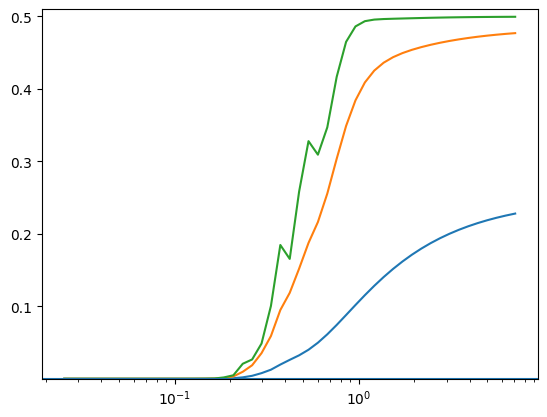

In [354]:
fake_k = 1/sqrt(taus*2)
X=1/2-dat
Y=1/2-dat2
Z=1/2-dat3
plot(fake_k,X)
plot(fake_k,Z)
plot(fake_k,Y)

xscale("log")
#yscale("log")
#xlim(fake_k[-1],1)
ylim(0.0001,.51)
plt.hlines(2.**(-L),taus[0],taus[-1])
#plt.vlines(2/3,0,.5)

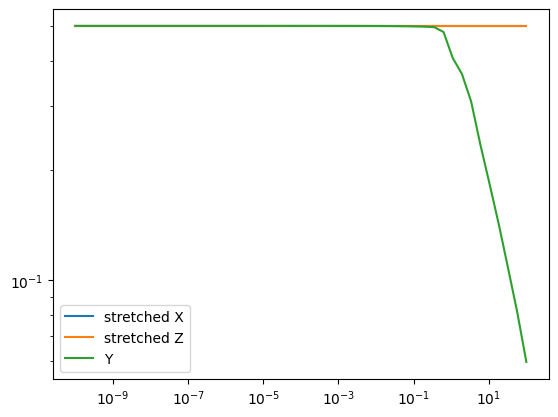

In [340]:
import numpy as np
import matplotlib.pyplot as plt

# given: taus, X, Y, Z
def stretch_to_Y(series, Y):
    s0, smax = series[0], np.max(series)
    Y0, Ymax = Y[0], np.max(Y)
    if smax != s0:
        a = (Ymax - Y0) / (smax - s0)
        b = Y0 - a * s0
        return a * series + b
    else:
        return np.full_like(series, Y0 if Ymax == Y0 else Ymax)

S = (X / X[0]) * Y[0]
T = stretch_to_Y(S, Y)

S_z = (Z / Z[0]) * Y[0]
T_z = stretch_to_Y(S_z, Y)

plt.plot(taus, T, label='stretched X')
plt.plot(taus, T_z, label='stretched Z')
plt.plot(taus, Y, label='Y')
plt.legend()
loglog()
plt.show()


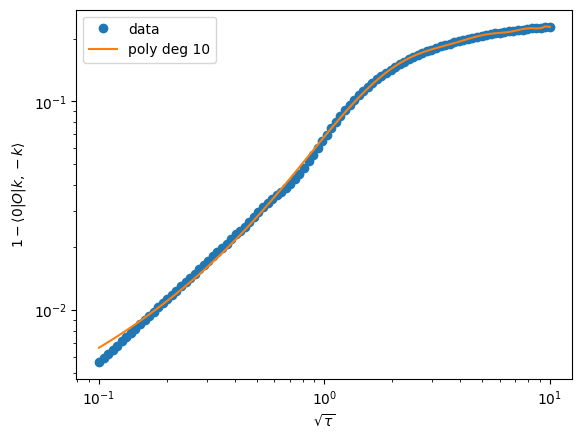

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial


# transform
x = 1/np.sqrt(taus)
y = dat

# fit to a polynomial of degree n
n = 10
p = Polynomial.fit(x, y, deg=n)
yfit = p(x)

# plot
plt.loglog(x, y, 'o', label='data')
plt.loglog(x, yfit, '-', label=f'poly deg {n}')
plt.xlabel(r'$\sqrt{\tau}$')
plt.ylabel(r'$1 - \langle 0|O|k,-k\rangle$')
plt.legend()
plt.show()


In [130]:
p

Polynomial([ 1.68734792e-01, -1.79554719e-01,  4.85411107e-01, -5.64851949e-03,
       -2.71693826e+00, -5.37601568e-01,  8.67086668e+00, -1.39914473e-01,
       -9.70408111e+00,  4.20974596e-01,  3.62776802e+00], domain=[ 0.1, 10. ], window=[-1.,  1.], symbol='x')

In [134]:
1/2/np.pi

0.15915494309189535